# 캐글 노트북 - Beginner Friendly CATBOOST with OPTUNA

## Data

Heart Failure Prediction Dataset

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold,cross_val_score, RepeatedStratifiedKFold,StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import OneHotEncoder,StandardScaler,PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier

import optuna
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer

from sklearn.model_selection import KFold, cross_val_predict, train_test_split,GridSearchCV,cross_val_score
from sklearn.metrics import accuracy_score,classification_report

#importing plotly and cufflinks in offline mode
import cufflinks as cf
import plotly.offline
cf.go_offline()
cf.set_config_file(offline=False, world_readable=True)

import plotly 
import plotly.express as px
import plotly.graph_objs as go
import plotly.offline as py
from plotly.offline import iplot
from plotly.subplots import make_subplots
import plotly.figure_factory as ff

import missingno as msno

import warnings
warnings.filterwarnings("ignore")

In [7]:
# pandas 출력 설정 -> 칼럼 행 출력 생략 방지
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 900)
pd.set_option('display.max_colwidth', 200)

df = pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [10]:
# 중복된 행이 몇 개인지 세는 코드
# 데이터 전처리할 때 중복 행 있으면 모델 학습에 영향 줄 수 있어서 초반에 꼭 확인
df.duplicated().sum()

np.int64(0)

In [12]:
# missing value가 있는 지 확인
def missing (df):
    missing_number = df.isnull().sum().sort_values(ascending=False)
    missing_percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
    missing_values = pd.concat([missing_number, missing_percent], axis=1, keys=['Missing_Number', 'Missing_Percent'])
    return missing_values

missing(df)

,Missing_Number,Missing_Percent
Age,0,0.0
Sex,0,0.0
ChestPainType,0,0.0
RestingBP,0,0.0
Cholesterol,0,0.0
FastingBS,0,0.0
RestingECG,0,0.0
MaxHR,0,0.0
ExerciseAngina,0,0.0
Oldpeak,0,0.0


In [14]:
# 수치형 변수와 범주형 변수로 데이터를 분리
numerical= df.drop(['HeartDisease'], axis=1).select_dtypes('number').columns # HeartDisease는 레이블이니까 drop
categorical = df.select_dtypes('object').columns

print(f'Numerical Columns:  {df[numerical].columns}')
print('\n')
print(f'Categorical Columns: {df[categorical].columns}')

Numerical Columns:  Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak'], dtype='object')


Categorical Columns: Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')


In [17]:
df[categorical].nunique()

# unique() 는 고유값을 직접 보여줌
# nunique() 는 고유값의 개수만 보여줌

Sex               2
ChestPainType     4
RestingECG        3
ExerciseAngina    2
ST_Slope          3
dtype: int64

=> zero variance(고유값이 1개/쓸모없는 칼럼): X  
=> extremely high variance(고유값이 너무 많음/수치형이 될 위험 O): X

## Exploratory Data Analysis

### Target Variable

In [21]:
y = df['HeartDisease']

# value_counts(normalize=True): 비율로 반환
print(f'Percentage of patient had a HeartDisease:  {round(y.value_counts(normalize=True)[1]*100,2)} %  --> ({y.value_counts()[1]} patient)')
print(f'Percentage of patient did not have a HeartDisease: {round(y.value_counts(normalize=True)[0]*100,2)}  %  --> ({y.value_counts()[0]} patient)')

Percentage of patient had a HeartDisease:  55.34 %  --> (508 patient)
Percentage of patient did not have a HeartDisease: 44.66  %  --> (410 patient)


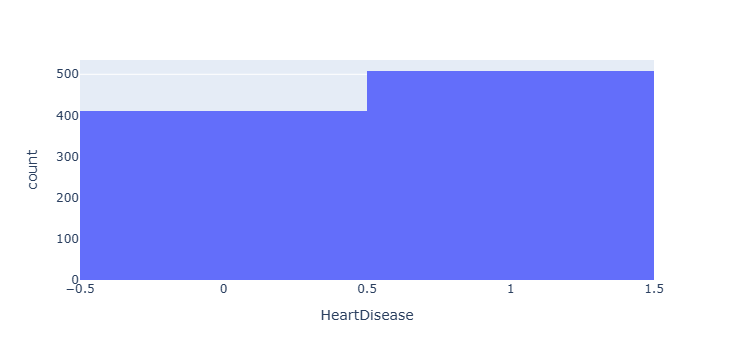

In [25]:
px.histogram(df, x='HeartDisease')

=> a little imblanace but nothing in the disturbing level

### Numerical Features

In [27]:
df[numerical].describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000


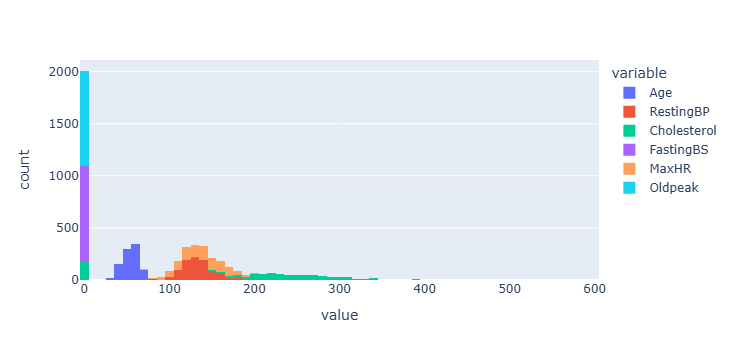

In [31]:
fig = px.histogram(df[numerical].melt(), x='value', color='variable')
fig.show()

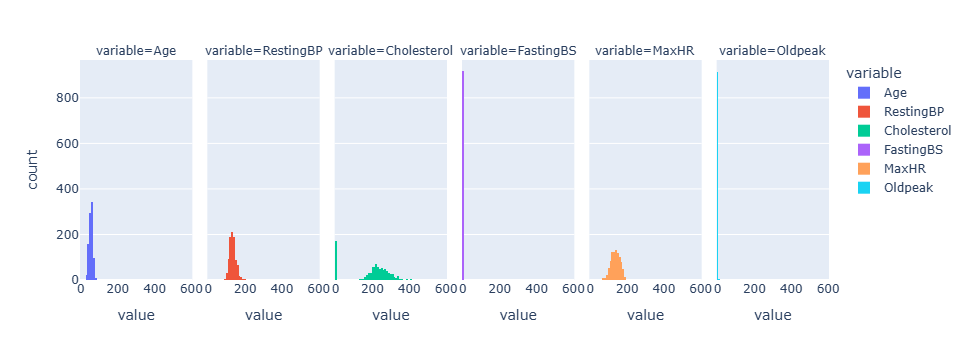

In [32]:
fig = px.histogram(df[numerical].melt(), x='value', facet_col='variable', color='variable')
fig.show()

In [34]:
# skewness 확인
# 0: 데이터가 좌우 대칭이면 왜도 = 0
# 양수: 오른쪽으로 꼬리가 긴 분포
# 음수: 왼쪽으로 꼬리가 긴 분포

skew_limit = 0.75 # This is our threshold-limit to evaluate skewness. Overall below abs(1) seems acceptable for the linear models. 
skew_vals = df[numerical].drop('FastingBS', axis=1).skew()
skew_cols= skew_vals[abs(skew_vals)> skew_limit].sort_values(ascending=False)
skew_cols

Oldpeak    1.022872
dtype: float64

In [40]:
df['FastingBS'].value_counts()

FastingBS
0    704
1    214
Name: count, dtype: int64

=> Nothing much for the skewness

<Axes: >

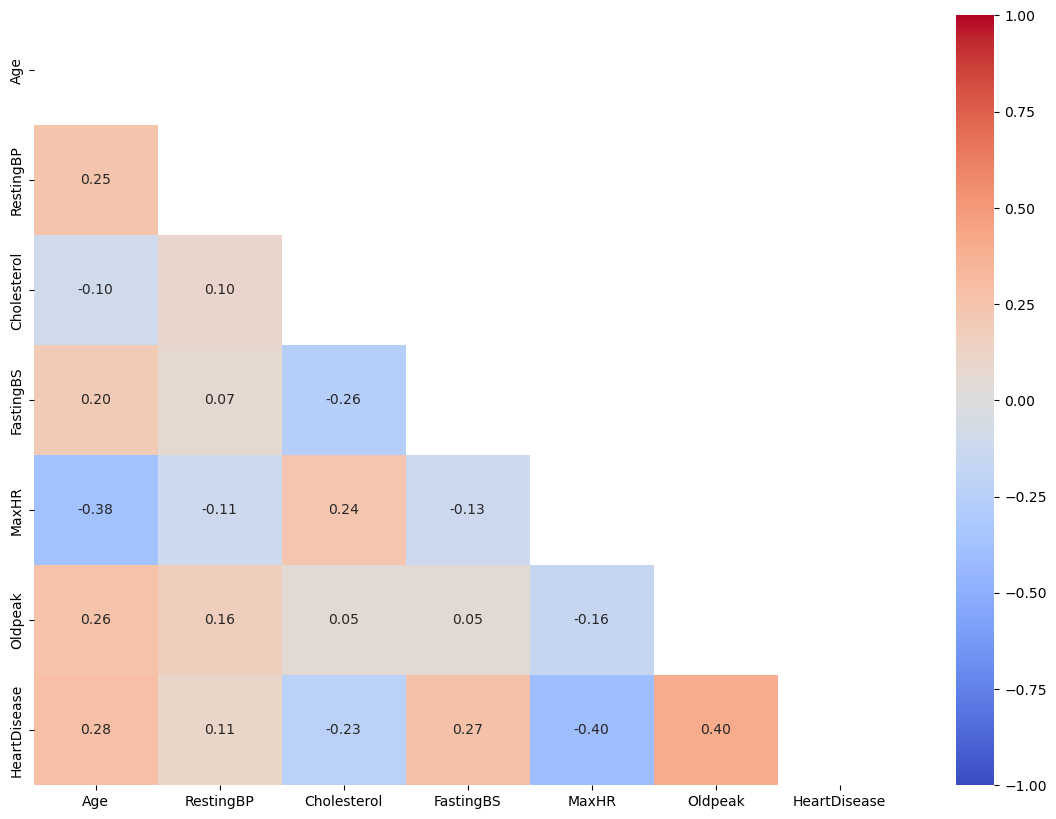

In [43]:
# numerical feature들과 label인 heartDisease에 대한 상관행렬(상삼각행렬을 마스크함)을 히트맵으로 출력

numerical1= df.select_dtypes('number').columns

matrix = np.triu(df[numerical1].corr())
fig, ax = plt.subplots(figsize=(14,10)) 
sns.heatmap (df[numerical1].corr(), annot=True, fmt= '.2f', vmin=-1, vmax=1, center=0, cmap='coolwarm',mask=matrix, ax=ax)

### Categorical Features

In [44]:
df[categorical].head()

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up


- Gender and Heart Disease

In [46]:
print (f'A female person has a probability of {round(df[df["Sex"]=="F"]["HeartDisease"].mean()*100,2)} % have a HeartDisease')
print()
print (f'A male person has a probability of {round(df[df["Sex"]=="M"]["HeartDisease"].mean()*100,2)} % have a HeartDisease')
print()

A female person has a probability of 25.91 % have a HeartDisease

A male person has a probability of 63.17 % have a HeartDisease



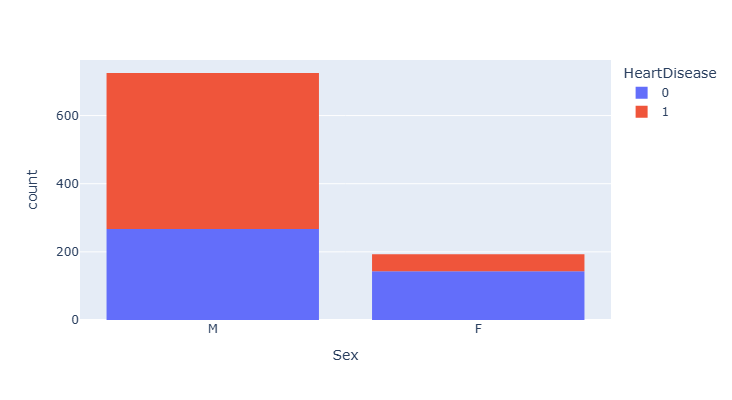

In [47]:
fig = px.histogram(df, x="Sex", color="HeartDisease",width=400, height=400)
fig.show()

=> Men are almost 2.44 times more likely have a heart disease than women.

- Chest Pain Type and Heart Disease

In [48]:
df.groupby('ChestPainType')['HeartDisease'].mean().sort_values(ascending=False)

ChestPainType
ASY    0.790323
TA     0.434783
NAP    0.354680
ATA    0.138728
Name: HeartDisease, dtype: float64

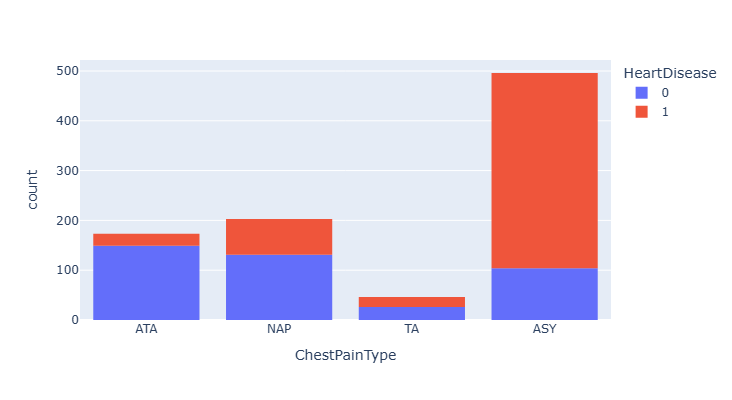

In [49]:
fig = px.histogram(df, x="ChestPainType", color="HeartDisease",width=400, height=400)
fig.show()

=> Person with ASY: Asymptomatic chest pain has almost 6 times more likely have a heart disease than person with ATA Atypical Angina chest pain.

- RestingECG and Heart Disease

In [50]:
df.groupby('RestingECG')['HeartDisease'].mean().sort_values(ascending=False)

RestingECG
ST        0.657303
LVH       0.563830
Normal    0.516304
Name: HeartDisease, dtype: float64

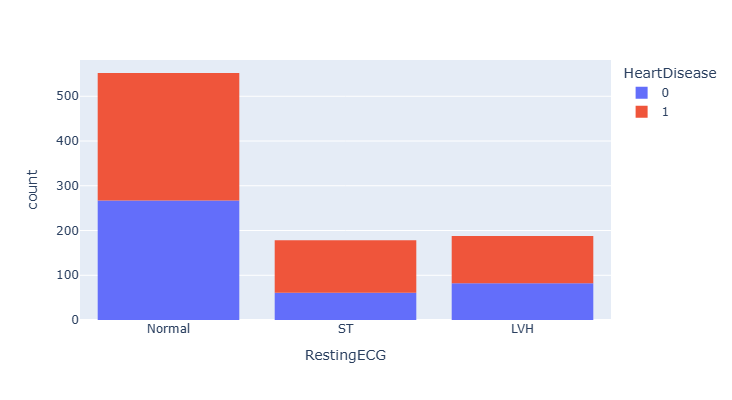

In [52]:
fig = px.histogram(df, x="RestingECG", color="HeartDisease",width=400, height=400)
fig.show()

=> RestingECG: resting electrocardiogram results don't differ much.  
=> Person with ST: having ST-T wave abnormality is more likely have a heart disease than the others.

- ExerciseAngina and Heart Disease

In [53]:
df.groupby('ExerciseAngina')['HeartDisease'].mean().sort_values(ascending=False)

ExerciseAngina
Y    0.851752
N    0.351005
Name: HeartDisease, dtype: float64

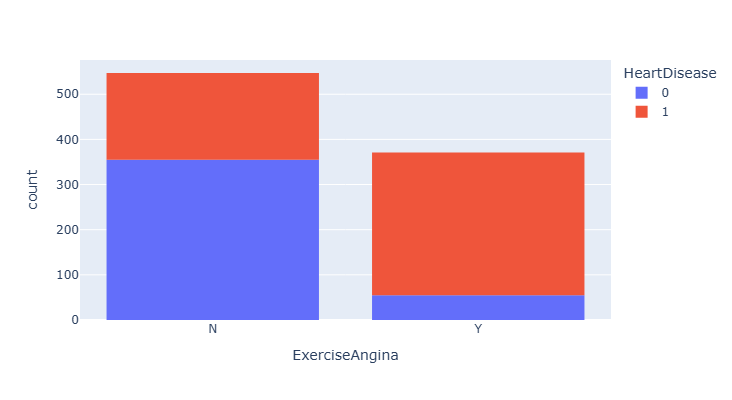

In [54]:
fig = px.histogram(df, x="ExerciseAngina", color="HeartDisease",width=400, height=400)
fig.show()

=> ExerciseAngina: exercise-induced angina with 'Yes' almost 2.4 times more likley have a heart disaese than exercise-induced angina with 'No'

- ST_Slope and Heart Disease

In [55]:
df.groupby('ST_Slope')['HeartDisease'].mean().sort_values(ascending=False)

ST_Slope
Flat    0.828261
Down    0.777778
Up      0.197468
Name: HeartDisease, dtype: float64

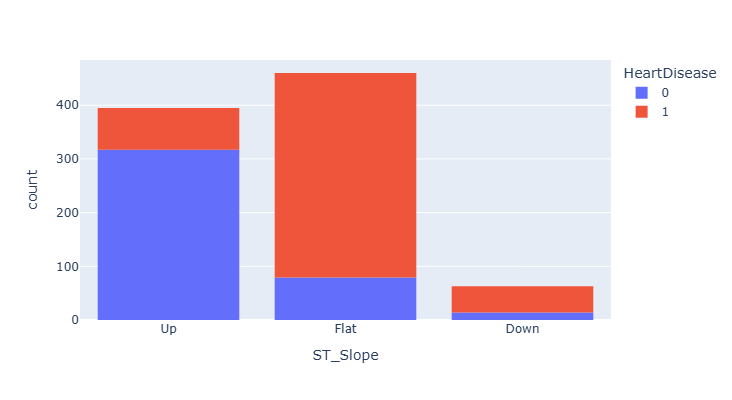

In [56]:
fig = px.histogram(df, x="ST_Slope", color="HeartDisease",width=400, height=400)
fig.show()

=> ST_Slope: the slope of the peak exercise ST segment has differences.  
=> ST_Slope Up significantly less likely has heart disease than the other two segment.

### Overall Insights from the Exploratory Data Analysis

- Target variable has close to **balanced data**.  
---
- Numerical features have weak correlation with the target variable.
- Oldpeak (depression related number) has a positive correlation with the heart disease.
- Maximum heart rate has negative correlation with the heart disease.
- cholesterol has negative correlation with the heart disease.  
---
- Based on the gender; Men are almost 2.44 times more likely have a heart disease than women.
- We can observe clear differences among the chest pain type.
- Person with ASY: Asymptomatic chest pain has almost 6 times more likely have a heart disease than person with ATA Atypical Angina chest pain.
- RestingECG: resting electrocardiogram results don't differ much.
- Person with ST: having ST-T wave abnormality is more likely have a heart disease than the others.
- ExerciseAngina: exercise-induced angina with 'Yes' almost 2.4 times more likley have a heart disaese than exercise-induced angina with 'No'
- ST_Slope: the slope of the peak exercise ST segment has differences.
- ST_Slope Up significantly less likely has heart disease than the other two segment.

## Model Selection

1. We'll use dummy classifier model as a base model
2. And then we will use Logistic & Linear Discriminant & KNeighbors and Support Vector Machine models with and without scaler.
3. And then we will use ensemble models, Adaboost, Randomforest, Gradient Boosting and Extra Trees
4. We will see famous trio: XGBoost,LightGBM & Catboost
5. Finally we will look in detail to hyperparameter tuning for Catboost

### Baseline Model

: 실제 학습을 하는 게 아니라 무조건 1만 예측하는 멍청한 모델 (strategy='constant', constant=1)  
-> 비교 기준점(베이스라인)을 만들기 위해  
=> 이후에 만드는 진짜 모델들이 이것보다는 높아야 "의미있는 모델" 이라고 할 수 있기 때문

In [57]:
accuracy =[]
model_names =[]


X= df.drop('HeartDisease', axis=1)
y= df['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ohe= OneHotEncoder()
ct= make_column_transformer((ohe,categorical),remainder='passthrough')  


model = DummyClassifier(strategy='constant', constant=1)
pipe = make_pipeline(ct, model)
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
accuracy.append(round(accuracy_score(y_test, y_pred),4))
print (f'model : {model} and  accuracy score is : {round(accuracy_score(y_test, y_pred),4)}')

model_names = ['DummyClassifier']
dummy_result_df = pd.DataFrame({'Accuracy':accuracy}, index=model_names)
dummy_result_df

model : DummyClassifier(constant=1, strategy='constant') and  accuracy score is : 0.5942


,Accuracy
DummyClassifier,0.5942


### Logistic & Linear Discriminant & SVC & KNN

-> 이 4개의 모델을 한번에 학습 예측 평가(for문 사용)

**make_pipeline() 함수란?**  
  
**<원래>**  
ct.fit_transform(X_train)  # 인코딩  
model.fit(X_train, y_train)  # 학습  
ct.transform(X_test)  # 테스트 인코딩  
model.predict(X_test)  # 예측  
  
**<make_pipeline() 사용>**  
pipeline으로 묶으면 이렇게 한 번에 돼요  
pythonpipe = make_pipeline(ct, model)  
pipe.fit(X_train, y_train)  # 인코딩 + 학습 한번에  
pipe.predict(X_test)  # 인코딩 + 예측 한번에  

In [58]:
accuracy =[]
model_names =[]


X= df.drop('HeartDisease', axis=1)
y= df['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ohe= OneHotEncoder()
ct= make_column_transformer((ohe,categorical),remainder='passthrough')  


lr = LogisticRegression(solver='liblinear')
lda= LinearDiscriminantAnalysis()
svm = SVC(gamma='scale')
knn = KNeighborsClassifier()

models = [lr,lda,svm,knn]

for model in models: 
    pipe = make_pipeline(ct, model)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    accuracy.append(round(accuracy_score(y_test, y_pred),4))
    print (f'model : {model} and  accuracy score is : {round(accuracy_score(y_test, y_pred),4)}')

model_names = ['Logistic','LinearDiscriminant','SVM','KNeighbors']
result_df1 = pd.DataFrame({'Accuracy':accuracy}, index=model_names)
result_df1

model : LogisticRegression(solver='liblinear') and  accuracy score is : 0.8841
model : LinearDiscriminantAnalysis() and  accuracy score is : 0.8696
model : SVC() and  accuracy score is : 0.7246
model : KNeighborsClassifier() and  accuracy score is : 0.7174


,Accuracy
Logistic,0.8841
LinearDiscriminant,0.8696
SVM,0.7246
KNeighbors,0.7174


### Logistic & Linear Discriminant & SVC & KNN with Scaler

-> 위의 코드에서 스케일링 추가 -> 수치형 컬럼에 StandardScaler도 적용

**StandardScaler란?**
- 수치형 데이터를 모두 같은 범위로 평균 0, 표준편차 1로 맞춰줌

**StandardScaler하는 이유**
- KNN, SVM 같은 모델은 거리 기반이라 스케일 차이에 민감해요
- 스케일링 전후 정확도를 비교해서 얼마나 차이나는지 보기 위해

In [59]:
accuracy =[]
model_names =[]


X= df.drop('HeartDisease', axis=1)
y= df['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ohe= OneHotEncoder()
s= StandardScaler()
ct1= make_column_transformer((ohe,categorical),(s,numerical))  


lr = LogisticRegression(solver='liblinear')
lda= LinearDiscriminantAnalysis()
svm = SVC(gamma='scale')
knn = KNeighborsClassifier()

models = [lr,lda,svm,knn]

for model in models: 
    pipe = make_pipeline(ct1, model)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    accuracy.append(round(accuracy_score(y_test, y_pred),4))
    print (f'model : {model} and  accuracy score is : {round(accuracy_score(y_test, y_pred),4)}')

model_names = ['Logistic_scl','LinearDiscriminant_scl','SVM_scl','KNeighbors_scl']
result_df2 = pd.DataFrame({'Accuracy':accuracy}, index=model_names)
result_df2

model : LogisticRegression(solver='liblinear') and  accuracy score is : 0.8804
model : LinearDiscriminantAnalysis() and  accuracy score is : 0.8696
model : SVC() and  accuracy score is : 0.8841
model : KNeighborsClassifier() and  accuracy score is : 0.8841


,Accuracy
Logistic_scl,0.8804
LinearDiscriminant_scl,0.8696
SVM_scl,0.8841
KNeighbors_scl,0.8841


### Ensemble Models (AdaBoost & Gradient Boosting & Random Forest & Extra Trees)

-> 앙상블 모델 비교

- 앙상블 종류
  - AdaBoostClassifier → 틀린 샘플에 가중치를 높여가며 학습
  - GradientBoostingClassifier → 이전 트리의 오차를 보완하며 학습
  - RandomForestClassifier → 여러 트리를 병렬로 만들어 다수결
  - **ExtraTreesClassifier → 랜덤포레스트랑 비슷한데 분기점을 완전 랜덤으로 정함**

- RandomForest vs ExtraTree
  - RandomForest → 분기점을 최적의 값으로 찾음 (50이 제일 좋다고 계산)
  - ExtraTree → 분기점을 그냥 랜덤으로 정함 (그냥 50)
    - ExtraTree가 더 빠른 but 랜덤이라 성능이 들쭉날쭉할 수 있음

In [60]:
accuracy =[]
model_names =[]


X= df.drop('HeartDisease', axis=1)
y= df['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ohe= OneHotEncoder()
ct= make_column_transformer((ohe,categorical),remainder='passthrough')  

ada = AdaBoostClassifier(random_state=0)
gb = GradientBoostingClassifier(random_state=0)
rf = RandomForestClassifier(random_state=0)
et=  ExtraTreesClassifier(random_state=0)



models = [ada,gb,rf,et]

for model in models: 
    pipe = make_pipeline(ct, model)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    accuracy.append(round(accuracy_score(y_test, y_pred),4))
    print (f'model : {model} and  accuracy score is : {round(accuracy_score(y_test, y_pred),4)}')

model_names = ['Ada','Gradient','Random','ExtraTree']
result_df3 = pd.DataFrame({'Accuracy':accuracy}, index=model_names)
result_df3

model : AdaBoostClassifier(random_state=0) and  accuracy score is : 0.8732
model : GradientBoostingClassifier(random_state=0) and  accuracy score is : 0.8768
model : RandomForestClassifier(random_state=0) and  accuracy score is : 0.8877
model : ExtraTreesClassifier(random_state=0) and  accuracy score is : 0.8804


,Accuracy
Ada,0.8732
Gradient,0.8768
Random,0.8877
ExtraTree,0.8804


### Famous Trio (XGBoost & LightGBM & Catboost)

In [61]:
accuracy =[]
model_names =[]


X= df.drop('HeartDisease', axis=1)
y= df['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ohe= OneHotEncoder()
ct= make_column_transformer((ohe,categorical),remainder='passthrough')  

xgbc = XGBClassifier(random_state=0)
lgbmc=LGBMClassifier(random_state=0)


models = [xgbc,lgbmc]

for model in models: 
    pipe = make_pipeline(ct, model)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    accuracy.append(round(accuracy_score(y_test, y_pred),4))

model_names = ['XGBoost','LightGBM']
result_df4 = pd.DataFrame({'Accuracy':accuracy}, index=model_names)
result_df4

,Accuracy
XGBoost,0.8478
LightGBM,0.8732


### CATBOOST

: **Cat**egorical **Boost**ing의 줄임말로, 러시아 회사 Yandex에서 만든 그래디언트 부스팅 계열 모델

- 다른 모델과의 차이점
  - 랜덤포레스트: 트리를 **병렬로** 여러 개 생성
  - CatBoost: 트리를 **순서대로** 생성하며 이전 트리의 오차를 다음 트리가 보완
- 특징
  - 범주형 변수를 **자동으로 처리** (`cat_features`만 지정하면 됨)
  - 별도의 Label Encoding, One-Hot Encoding 불필요
- 기본 목적함수 자동 선택
  - 타겟이 2개 (0, 1) → **Logloss**
  - 타겟이 3개 이상 → **MultiClass**

In [64]:
accuracy =[]
model_names =[]


X= df.drop('HeartDisease', axis=1)
y= df['HeartDisease']
categorical_features_indices = np.where(X.dtypes != float)[0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = CatBoostClassifier(verbose=False,random_state=0)

model.fit(X_train, y_train,cat_features=categorical_features_indices,eval_set=(X_test, y_test))
y_pred = model.predict(X_test)
accuracy.append(round(accuracy_score(y_test, y_pred),4))

model_names = ['Catboost_default']
result_df5 = pd.DataFrame({'Accuracy':accuracy}, index=model_names)
result_df5

,Accuracy
Catboost_default,0.8804


### Catboost HyperParameter Tuning with Optuna

**Optuna vs Hyperopt**
- 탐색 방식
  - Hyperopt → TPE(Tree-structured Parzen Estimator) 방식만 지원
  - Optuna → TPE 포함 여러 방식 지원하고 자동으로 골라줌
- 사용 편의성
  - Hyperopt → 탐색 공간을 따로 딕셔너리로 정의해야 해서 코드가 복잡
  - Optuna → trial.suggest_int, trial.suggest_float 이렇게 함수 안에서 바로 정의해서 직관적
- 시각화
  - Hyperopt → 시각화 기능 거의 없음
  - Optuna → 자체 시각화 기능이 있어서 trial 결과를 그래프로 볼 수 있음
- 결론: 요즘은 Optuna를 더 많이 씀 -> 코드도 깔끔하고 기능도 많기 때문

In [66]:
def objective(trial):
    X= df.drop('HeartDisease', axis=1)
    y= df['HeartDisease']
    categorical_features_indices = np.where(X.dtypes != float)[0]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    param = {
        "objective": trial.suggest_categorical("objective", ["Logloss", "CrossEntropy"]),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.01, 0.1),
        "depth": trial.suggest_int("depth", 1, 12),
        "boosting_type": trial.suggest_categorical("boosting_type", ["Ordered", "Plain"]),
        "bootstrap_type": trial.suggest_categorical(
            "bootstrap_type", ["Bayesian", "Bernoulli", "MVS"]
        ),
        "used_ram_limit": "3gb",
    }

    if param["bootstrap_type"] == "Bayesian":
        param["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0, 10)
    elif param["bootstrap_type"] == "Bernoulli":
        param["subsample"] = trial.suggest_float("subsample", 0.1, 1)

    cat_cls = CatBoostClassifier(**param)

    cat_cls.fit(X_train, y_train, eval_set=[(X_test, y_test)], cat_features=categorical_features_indices,verbose=0, early_stopping_rounds=100)

    preds = cat_cls.predict(X_test)
    pred_labels = np.rint(preds)
    accuracy = accuracy_score(y_test, pred_labels)
    return accuracy


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, timeout=600)

print("Number of finished trials: {}".format(len(study.trials)))

print("Best trial:")
trial = study.best_trial

print("  Value: {}".format(trial.value))

print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

[I 2026-04-04 16:24:08,042] A new study created in memory with name: no-name-67f24232-3f06-4cd7-a003-2ec4aa382cee
[I 2026-04-04 16:24:30,237] Trial 0 finished with value: 0.8804347826086957 and parameters: {'objective': 'Logloss', 'colsample_bylevel': 0.08538278159191186, 'depth': 3, 'boosting_type': 'Ordered', 'bootstrap_type': 'Bernoulli', 'subsample': 0.9864055943532869}. Best is trial 0 with value: 0.8804347826086957.
[I 2026-04-04 16:24:51,657] Trial 1 finished with value: 0.8913043478260869 and parameters: {'objective': 'CrossEntropy', 'colsample_bylevel': 0.053192140711458245, 'depth': 11, 'boosting_type': 'Plain', 'bootstrap_type': 'MVS'}. Best is trial 1 with value: 0.8913043478260869.
[I 2026-04-04 16:25:05,706] Trial 2 finished with value: 0.8876811594202898 and parameters: {'objective': 'CrossEntropy', 'colsample_bylevel': 0.07165640537597785, 'depth': 1, 'boosting_type': 'Ordered', 'bootstrap_type': 'MVS'}. Best is trial 1 with value: 0.8913043478260869.
[I 2026-04-04 16:2

Number of finished trials: 34
Best trial:
  Value: 0.8985507246376812
  Params: 
    objective: CrossEntropy
    colsample_bylevel: 0.019895293273417818
    depth: 8
    boosting_type: Ordered
    bootstrap_type: MVS


In [73]:
# 최적의 파라미터로 다시 학습해서 성능 평가 결과까지 출력

In [68]:
accuracy =[]
model_names =[]


X= df.drop('HeartDisease', axis=1)
y= df['HeartDisease']
categorical_features_indices = np.where(X.dtypes != float)[0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = CatBoostClassifier(verbose=False,random_state=0,
                          objective= 'CrossEntropy',
    colsample_bylevel= 0.04292240490294766,
    depth= 10,
    boosting_type= 'Plain',
    bootstrap_type= 'MVS')

model.fit(X_train, y_train,cat_features=categorical_features_indices,eval_set=(X_test, y_test))
y_pred = model.predict(X_test)
accuracy.append(round(accuracy_score(y_test, y_pred),4))
print(classification_report(y_test, y_pred))

model_names = ['Catboost_tuned']
result_df6 = pd.DataFrame({'Accuracy':accuracy}, index=model_names)
result_df6

              precision    recall  f1-score   support

           0       0.88      0.90      0.89       112
           1       0.93      0.91      0.92       164

    accuracy                           0.91       276
   macro avg       0.90      0.91      0.91       276
weighted avg       0.91      0.91      0.91       276



,Accuracy
Catboost_tuned,0.9094


### Feature Importance

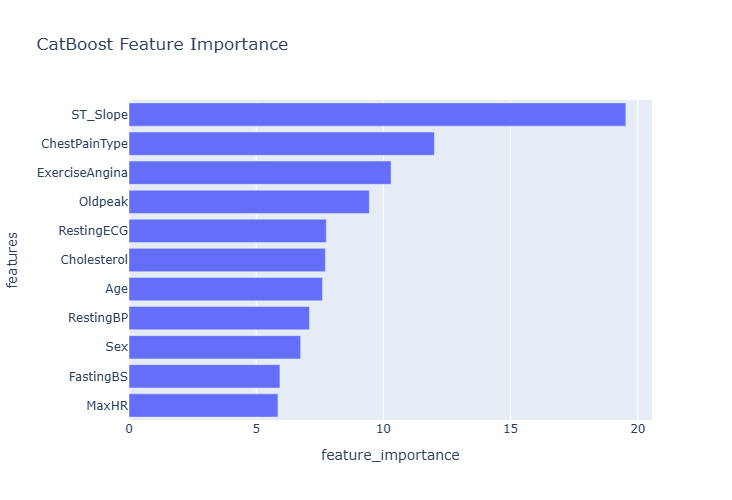

In [69]:
feature_importance = np.array(model.get_feature_importance())
features = np.array(X_train.columns)
fi={'features':features,'feature_importance':feature_importance}
df_fi = pd.DataFrame(fi)
df_fi.sort_values(by=['feature_importance'], ascending=True,inplace=True)
fig = px.bar(df_fi, x='feature_importance', y='features',title="CatBoost Feature Importance",height=500)
fig.show()

### Model Comparison

In [70]:
result_final = pd.concat([dummy_result_df,result_df1,result_df2,result_df3,result_df4,result_df5,result_df6],axis=0)

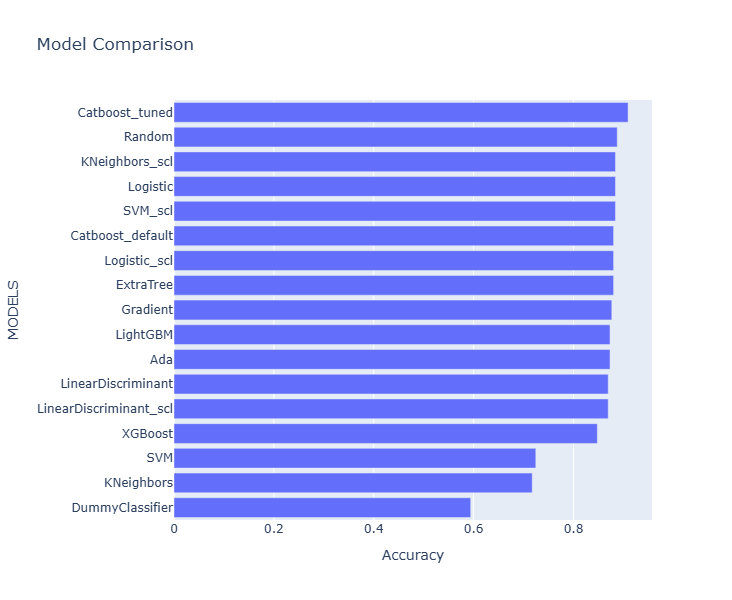

In [71]:
result_final.sort_values(by=['Accuracy'], ascending=True,inplace=True)
fig = px.bar(result_final, x='Accuracy', y=result_final.index,title='Model Comparison',height=600,labels={'index':'MODELS'})
fig.show()